In [12]:
from pathlib import Path
import itertools
import json
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.optimize import minimize

# Keep the legacy M3 fit helper used by the later notebook cells.
M3_HELPER_DIR = Path(
    "/home/rebeccaz/Programs/VAMPIRES/vampires_calibration/"
    "vampires_on_sky_calibration/programs/unpolarized/matrix_inversion"
)
LEGACY_MATRIX_HELPER_DIR = Path(
    "/home/rebeccaz/Programs/VAMPIRES/vampires_calibration/"
    "vampires_on_sky_calibration/programs/py_files"
)
if str(LEGACY_MATRIX_HELPER_DIR) not in sys.path:
    sys.path.insert(0, str(LEGACY_MATRIX_HELPER_DIR))
if str(M3_HELPER_DIR) not in sys.path:
    sys.path.insert(0, str(M3_HELPER_DIR))

import scipy_minimize_m3 as m3

PYPOLCAL_ROOT = Path("/home/rebeccaz/Github/pyPolCal")
if str(PYPOLCAL_ROOT) not in sys.path:
    sys.path.insert(0, str(PYPOLCAL_ROOT))

from pyPolCal.utils import (
    generate_system_mueller_matrix,
    parse_configuration,
    update_system_mm,
)


# Setting Up Initial Instrument Parameters

In [13]:
# Build the pyPolCal VAMPIRES instrument model used for HWP-frame inversion.
# This keeps the same fitted-component JSON file already referenced by this notebook.
mueller_matrix_file = Path(
    "/home/rebeccaz/Github/vampires_calibration/mcmc/start_txt_files/"
    "FLC_0_43_dichroic_theta_0_pm_10_optics_theta_0_optics_retardance_025/"
    "720nm.txt"
)

# Match the fixed IPOL Wollaston transmission ratio used by the pyPolCal VAMPIRES fits.
transmission_ratio = 1.18
em_gain = transmission_ratio

with mueller_matrix_file.open("r", encoding="utf-8") as f:
    mueller_data = json.load(f)

# Ordered downstream to upstream, matching pyPolCal's SystemMuellerMatrix convention.
# The internal-calibration linear polarizer is intentionally excluded for on-sky data.
system_dict = {
    "components": {
        "wollaston": {
            "type": "wollaston_prism_function",
            "properties": {"beam": "o", "transmission_ratio": transmission_ratio},
        },
        "dichroic": {
            "type": "diattenuator_retarder_function",
            "properties": {"phi": 0, "epsilon": 0, "theta": 0},
        },
        "flc": {
            "type": "general_retarder_function",
            "properties": {"phi": 0.5 * 2 * np.pi, "theta": 0, "delta_theta": 0},
        },
        "optics": {
            "type": "diattenuator_retarder_function",
            "properties": {"phi": 0, "epsilon": 0, "theta": 0},
        },
        "image_rotator": {
            "type": "general_retarder_function",
            "properties": {"phi": 0.5 * 2 * np.pi, "theta": 0, "delta_theta": 0},
        },
        "hwp": {
            "type": "general_retarder_function",
            "properties": {"phi": 0.5, "theta": 0, "delta_theta": 0},
        },
    }
}

system_mm = generate_system_mueller_matrix(system_dict)

instrument_fit_parameters = {
    name: values
    for name, values in mueller_data.items()
    if name in system_dict["components"]
}
ignored_fit_components = sorted(set(mueller_data) - set(instrument_fit_parameters))

fixed_param_values, fixed_param_keywords = parse_configuration(instrument_fit_parameters)
system_mm = update_system_mm(fixed_param_values, fixed_param_keywords, system_mm)

print(f"Loaded pyPolCal instrument fit from: {mueller_matrix_file}")
print(f"Applied fitted components: {sorted(instrument_fit_parameters)}")
print(f"Ignored on-sky-inapplicable fitted components: {ignored_fit_components}")
print(f"Wollaston transmission ratio: {transmission_ratio}")


Loaded pyPolCal instrument fit from: /home/rebeccaz/Github/vampires_calibration/mcmc/start_txt_files/FLC_0_43_dichroic_theta_0_pm_10_optics_theta_0_optics_retardance_025/720nm.txt
Applied fitted components: ['dichroic', 'flc', 'hwp', 'image_rotator', 'optics']
Ignored on-sky-inapplicable fitted components: ['lp']
Wollaston transmission ratio: 1.18


# Load .csv files

In [14]:
csv_directory = Path(
    "/home/rebeccaz/Github/vampires_calibration/on-sky/data/unpolarized/"
    "CoG_Aperture_Annulus_Background_Subtraction"
)
csv_files = sorted(csv_directory.glob("*.csv"))

if not csv_files:
    raise FileNotFoundError(f"No CSV files found in {csv_directory.resolve()}")

all_data = pd.concat((pd.read_csv(file) for file in csv_files), ignore_index=True)

required_columns = {
    "OBJECT",
    "U_HWPANG",
    "D_IMRANG",
    "ALTITUDE",
    "Q",
    "U",
    "DOUBLE_DIFFERENCE",
    "DOUBLE_SUM",
    "DOUBLE_DIFFERENCE_ERRS",
}
missing_columns = sorted(required_columns - set(all_data.columns))
if missing_columns:
    raise KeyError(f"Missing required CSV columns: {missing_columns}")

print(f"Loaded {len(csv_files)} CoG/annulus CSV files from {csv_directory.resolve()}")
print(f"Combined rows: {len(all_data)}")


Loaded 6 CoG/annulus CSV files from /home/rebeccaz/Github/vampires_calibration/on-sky/data/unpolarized/CoG_Aperture_Annulus_Background_Subtraction
Combined rows: 1388


# Plotting the Data in the HWP angle frame

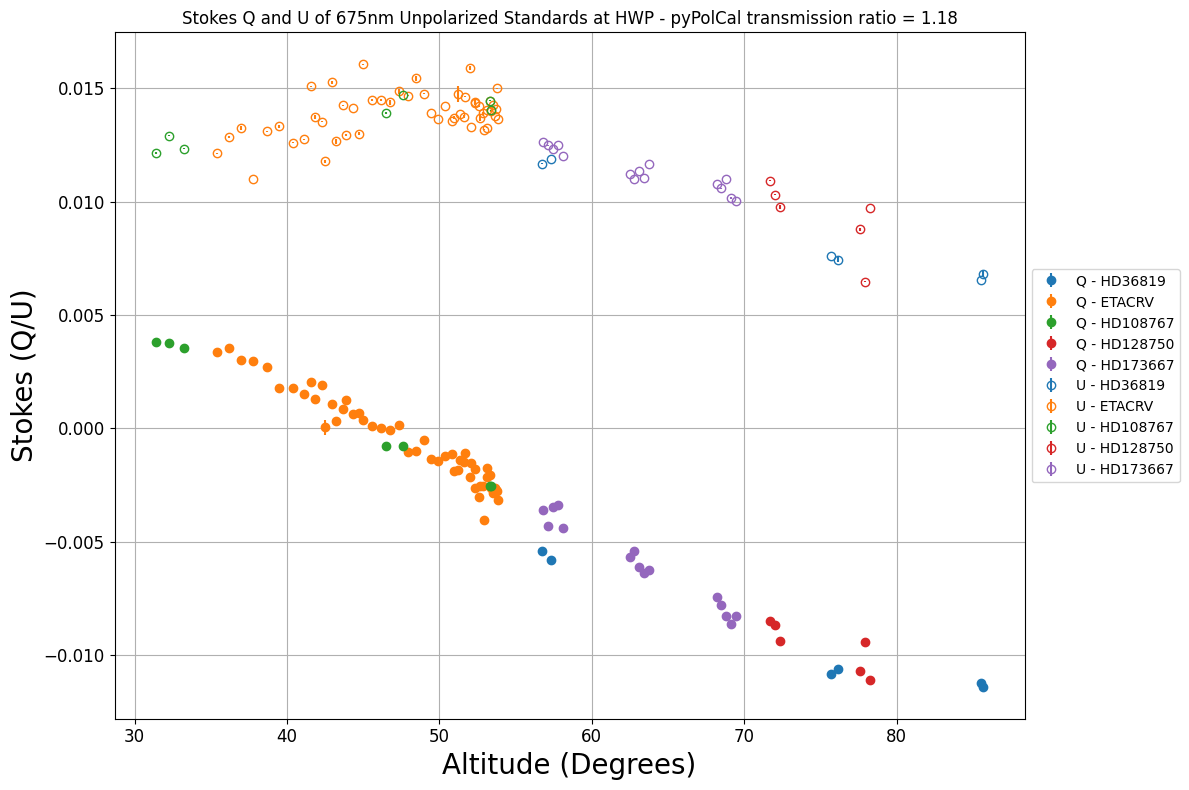

In [15]:
import itertools
import numpy as np
import matplotlib.pyplot as plt


def _configured_first_row(hwp_angle, imr_angle, flc_theta, beam):
    values, keywords = parse_configuration(
        {
            "hwp": {"theta": float(hwp_angle)},
            "image_rotator": {"theta": float(imr_angle)},
            "flc": {"theta": float(flc_theta)},
            "wollaston": {"beam": beam},
        }
    )
    update_system_mm(values, keywords, system_mm)
    return np.asarray(system_mm.evaluate(), dtype=float)[0, :]


def pypolcal_normalized_double_difference_row(hwp_angle, imr_angle):
    o_flc_1 = _configured_first_row(hwp_angle, imr_angle, flc_theta=0, beam="o")
    e_flc_1 = _configured_first_row(hwp_angle, imr_angle, flc_theta=0, beam="e")
    o_flc_2 = _configured_first_row(hwp_angle, imr_angle, flc_theta=45, beam="o")
    e_flc_2 = _configured_first_row(hwp_angle, imr_angle, flc_theta=45, beam="e")

    double_difference_row = (o_flc_1 - e_flc_1) - (o_flc_2 - e_flc_2)
    double_sum_row = (o_flc_1 + e_flc_1) + (o_flc_2 + e_flc_2)
    unpolarized_sum = double_sum_row[0]

    if np.isclose(unpolarized_sum, 0):
        raise ZeroDivisionError(
            f"pyPolCal double-sum normalization vanished at HWP={hwp_angle}, IMR={imr_angle}"
        )

    return double_difference_row / unpolarized_sum


# Extract unique objects and generate colors
unique_objects = all_data["OBJECT"].unique()
TARGET_COLOR_MAP = {
    "HD173667": "tab:blue",
    "HD36819": "tab:orange",
    "HD128750": "tab:green",
    "ETACRV": "tab:red",
    "HD108767": "tab:purple",
}


def normalize_target_name(target):
    return str(target).upper().replace(" ", "").replace("_", "")


def color_for_target(target):
    return TARGET_COLOR_MAP.get(normalize_target_name(target), "tab:gray")

# Initialize lists for storing the results
wavelength = 675
Q_list = []
U_list = []
Q_err_list = []
U_err_list = []
final_altitudes = []

# Loop through each unique object
for obj in unique_objects:
    object_data = all_data[all_data["OBJECT"] == obj]
    color = color_for_target(obj)

    # Initialize lists for this object
    response_rows = []
    this_cycle_intensities = []
    this_cycle_altitudes = []
    this_cycle_errors = []

    for _, row in object_data.iterrows():
        hwp_angle = row["U_HWPANG"]
        imr_angle = row["D_IMRANG"]
        altitude = row["ALTITUDE"]
        data_q = row["Q"]
        data_u = row["U"]

        double_difference = row["DOUBLE_DIFFERENCE"]
        double_difference_err = row["DOUBLE_DIFFERENCE_ERRS"]

        if pd.notna(double_difference) and not np.isclose(double_difference, 0):
            this_cycle_intensities.append(float(double_difference))
            this_cycle_altitudes.append(float(altitude))
            this_cycle_errors.append(float(double_difference_err))
            response_rows.append(
                pypolcal_normalized_double_difference_row(hwp_angle, imr_angle)
            )

        cycle_finished = (
            (pd.notna(data_q) and not np.isclose(data_q, 0))
            or (pd.notna(data_u) and not np.isclose(data_u, 0))
        )
        if cycle_finished and response_rows:
            measurement_matrix = np.vstack(response_rows)
            measurements = (
                np.asarray(this_cycle_intensities, dtype=float).reshape(-1, 1)
                - measurement_matrix[:, 0].reshape(-1, 1)
            )
            errors = np.asarray(this_cycle_errors, dtype=float).reshape(-1, 1)

            # Preserve the legacy inversion structure: solve for an I offset, Q, and U.
            measurement_matrix[:, 0] = 1
            inverse_matrix = np.linalg.pinv(measurement_matrix[:, :-1])
            s_hwp = inverse_matrix @ measurements
            s_hwp_err = inverse_matrix @ errors

            q_value = float(np.ravel(s_hwp[1])[0])
            u_value = float(np.ravel(s_hwp[2])[0])
            q_err = float(np.ravel(s_hwp_err[1])[0])
            u_err = float(np.ravel(s_hwp_err[2])[0])

            Q_list.append((float(altitude), q_value, color, obj))
            U_list.append((float(altitude), u_value, color, obj))
            Q_err_list.append(q_err)
            U_err_list.append(u_err)
            final_altitudes.append(float(np.mean(this_cycle_altitudes)))

            response_rows = []
            this_cycle_intensities = []
            this_cycle_altitudes = []
            this_cycle_errors = []

Q_err_list = np.abs(Q_err_list)
U_err_list = np.abs(U_err_list)

plt.figure(figsize=(12, 8))
plotted_labels = set()
for (altitude, q_value, color, obj), q_err in zip(Q_list, Q_err_list):
    label = f"Q - {obj}" if f"Q - {obj}" not in plotted_labels else None
    plt.errorbar(
        altitude,
        q_value,
        yerr=q_err,
        label=label,
        linestyle="None",
        marker="o",
        color=color,
        markerfacecolor=color,
    )
    plotted_labels.add(f"Q - {obj}")

for (altitude, u_value, color, obj), u_err in zip(U_list, U_err_list):
    label = f"U - {obj}" if f"U - {obj}" not in plotted_labels else None
    plt.errorbar(
        altitude,
        u_value,
        yerr=u_err,
        label=label,
        linestyle="None",
        marker="o",
        color=color,
        markerfacecolor="none",
        markeredgecolor=color,
    )
    plotted_labels.add(f"U - {obj}")

plt.title(
    f"Stokes Q and U of {wavelength}nm Unpolarized Standards at HWP "
    f"- pyPolCal transmission ratio = {em_gain}"
)
plt.xlabel("Altitude (Degrees)")
plt.ylabel("Stokes (Q/U)")
plt.legend(loc="center left", bbox_to_anchor=(1, 0.5))
plt.grid(True)
plt.tight_layout()
plt.show()


# Fitting for Matrix Inverted Values

Best Fit M3 Diattenuation: 0.013654782151469173
Best Fit Offset: -2.459569446489333


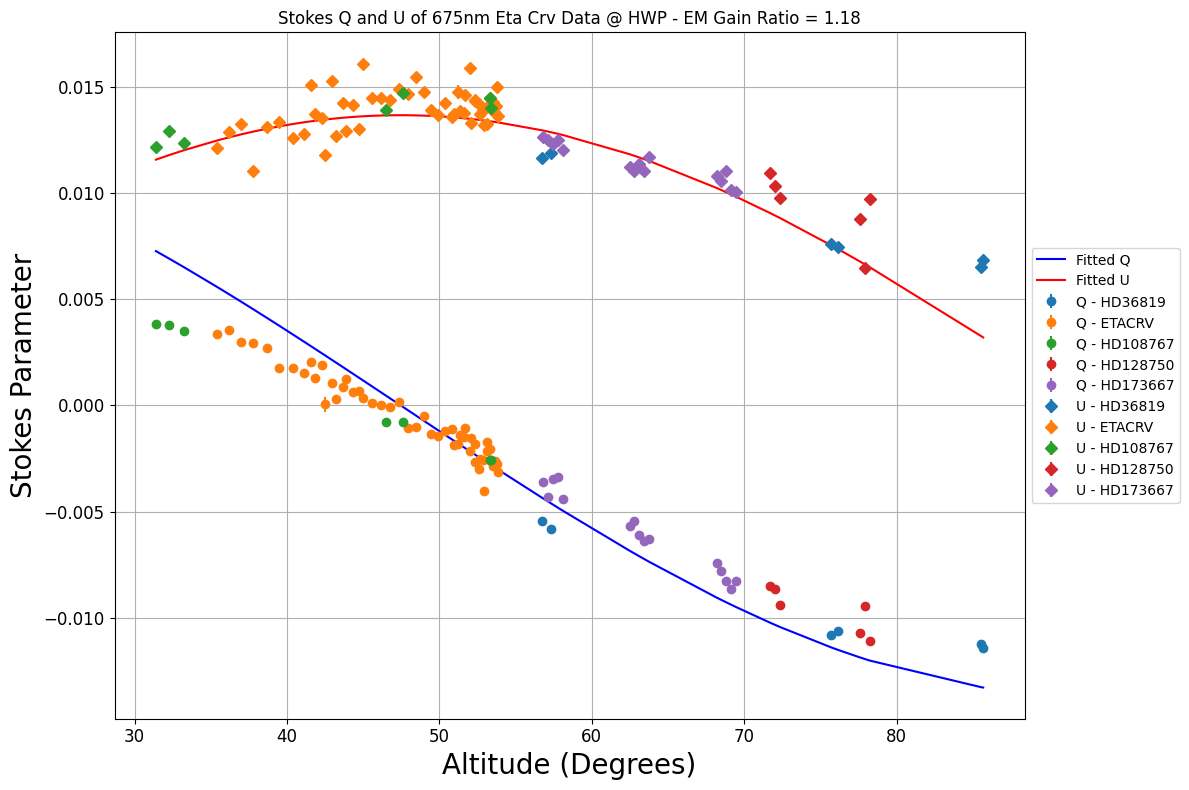

In [16]:
# Extract altitudes, Q_data, and U_data from the previous block of code
altitudes = [item[0] for item in Q_list]  # Extracting altitudes from Q_list (they are the same for U_list)
Q_data = np.array([item[1] for item in Q_list]).flatten()
U_data = np.array([item[1] for item in U_list]).flatten()

# Initial guesses for delta_m3, epsilon_m3, and offset
initial_guesses = [0, 0.01, 1]
bounds = [(0, 1), (-0.5, 0.5), (-10, 10)]

# Perform the minimization using Nelder-Mead with bounds
result = minimize(m3.residuals, initial_guesses, args=(altitudes, Q_data, U_data), method='Nelder-Mead', bounds=bounds)

# Extract the best-fit parameters
delta_m3_best, epsilon_m3_best, offset_best = result.x

print("Best Fit M3 Diattenuation: " + str(epsilon_m3_best))
print("Best Fit Offset: " + str(offset_best))

# Calculate the fitted Q and U values
Q_fitted, U_fitted = m3.propagate_unpol_source(delta_m3_best, epsilon_m3_best, offset_best, altitudes)
#Q_fitted, U_fitted = m3.propagate_unpol_source(0, 0.0176, -2.5, altitudes)

# Sort the fitted values by altitude
sorted_indices = np.argsort(altitudes)
altitudes_sorted = np.array(altitudes)[sorted_indices]
Q_fitted_sorted = Q_fitted[sorted_indices]
U_fitted_sorted = U_fitted[sorted_indices]

# Plotting the data and the fitted line
plt.figure(figsize=(12, 8))
plotted_labels = set()
for (altitude, Q, color, obj), Q_err in zip(Q_list, Q_err_list):
    label = f'Q - {obj}' if f'Q - {obj}' not in plotted_labels else None
    plt.errorbar(altitude, Q, yerr=Q_err, label=label, linestyle='None', marker='o', color=color, markerfacecolor=color)
    plotted_labels.add(f'Q - {obj}')

for (altitude, U, color, obj), U_err in zip(U_list, U_err_list):
    label = f'U - {obj}' if f'U - {obj}' not in plotted_labels else None
    plt.errorbar(altitude, U, yerr=U_err, label=label, linestyle='None', marker='D', color=color, markerfacecolor=color, markeredgecolor=color)
    plotted_labels.add(f'U - {obj}')

# Plot the fitted line with different colors for Q and U
plt.plot(altitudes_sorted, Q_fitted_sorted, label='Fitted Q', linestyle='-', color='blue')
plt.plot(altitudes_sorted, U_fitted_sorted, label='Fitted U', linestyle='-', color='red')

plt.title(f"Stokes Q and U of {wavelength}nm Eta Crv Data @ HWP - EM Gain Ratio = " + str(em_gain))
plt.xlabel("Altitude (Degrees)")
plt.ylabel("Stokes Parameter")
plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))
plt.grid(True)
plt.tight_layout()
plt.show()


# Errorbars with Bootstrapping Instead

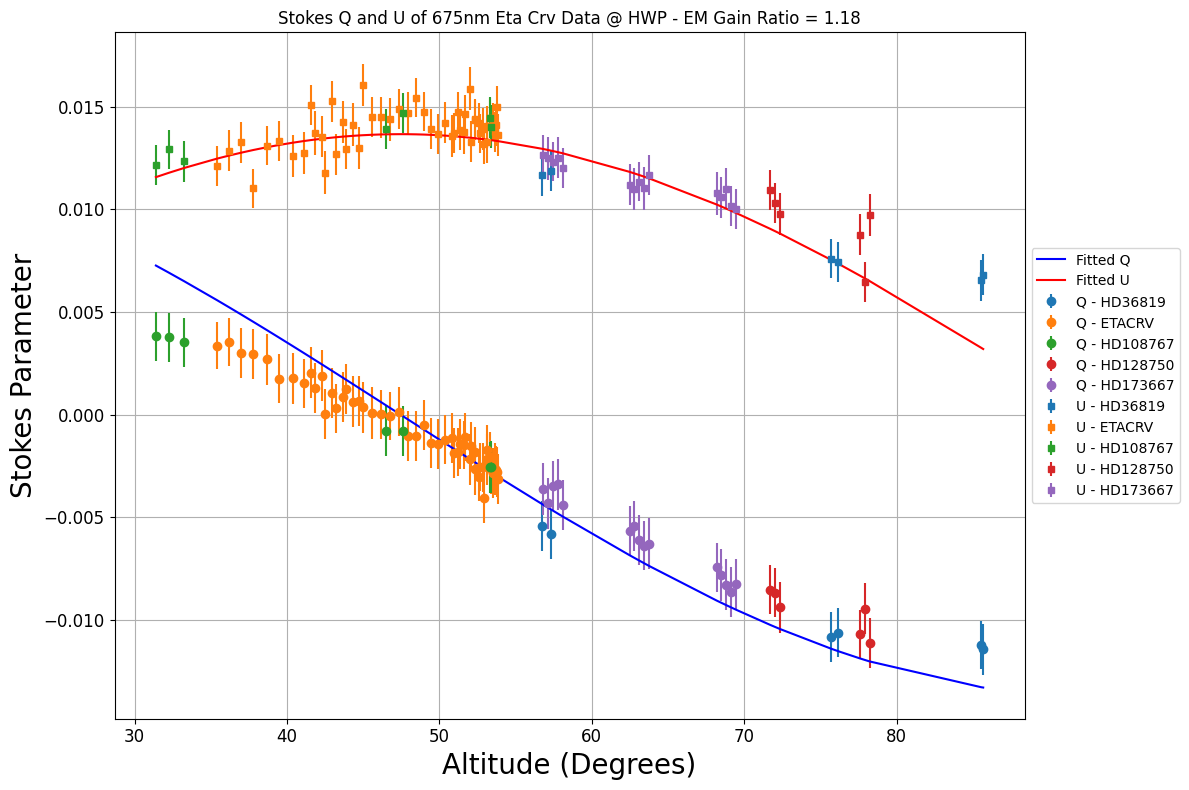

In [17]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize
import itertools

# Assuming 'all_data', 'fixed_params', 'matrices', and 'double_diff_factor' are already defined elsewhere in your code

# Extract altitudes, Q_data, and U_data from the previous block of code
altitudes = [item[0] for item in Q_list]  # Extracting altitudes from Q_list (they are the same for U_list)
Q_data = np.array([item[1] for item in Q_list]).flatten()
U_data = np.array([item[1] for item in U_list]).flatten()

# # Initial guesses for delta_m3, epsilon_m3, and offset
# initial_guesses = [0, 0.01, 1]
# bounds = [(0, 1), (-0.5, 0.5), (-10, 10)]

# # Perform the minimization using Nelder-Mead with bounds
# result = minimize(lambda params: np.sum(m3.residuals(params, altitudes, Q_data, U_data)**2), initial_guesses, bounds=bounds)

# # Extract the best-fit parameters
# delta_m3_best, epsilon_m3_best, offset_best = result.x

# print("Best Fit M3 Diattenuation: " + str(epsilon_m3_best))
# print("Best Fit Offset: " + str(offset_best))

# # Calculate the fitted Q and U values
# Q_fitted, U_fitted = m3.propagate_unpol_source(delta_m3_best, epsilon_m3_best, offset_best, altitudes)

# Calculate the residuals
Q_residuals = Q_data - Q_fitted
U_residuals = U_data - U_fitted

# Implement bootstrapping for error estimation
n_iterations = 1000
Q_bootstrap = np.zeros((n_iterations, len(Q_data)))
U_bootstrap = np.zeros((n_iterations, len(U_data)))

for i in range(n_iterations):
    sample_indices = np.random.choice(len(Q_data), len(Q_data), replace=True)
    Q_sample_residuals = Q_residuals[sample_indices]
    U_sample_residuals = U_residuals[sample_indices]
    Q_bootstrap[i, :] = Q_fitted + Q_sample_residuals
    U_bootstrap[i, :] = U_fitted + U_sample_residuals

# Calculate the standard deviation of the bootstrap samples
Q_err_bootstrap = np.std(Q_bootstrap, axis=0)
U_err_bootstrap = np.std(U_bootstrap, axis=0)

# Plotting the data and the fitted line
plt.figure(figsize=(12, 8))
plotted_labels = set()
for (altitude, Q, color, obj), Q_err in zip(Q_list, Q_err_bootstrap):
    label = f'Q - {obj}' if f'Q - {obj}' not in plotted_labels else None
    plt.errorbar(altitude, Q, yerr=Q_err, label=label, linestyle='None', marker='o', color=color, markerfacecolor=color)
    plotted_labels.add(f'Q - {obj}')

for (altitude, U, color, obj), U_err in zip(U_list, U_err_bootstrap):
    label = f'U - {obj}' if f'U - {obj}' not in plotted_labels else None
    plt.errorbar(altitude, U, yerr=U_err, label=label, linestyle='None', marker='s', color=color, markerfacecolor=color, markeredgecolor=color, markersize=5)
    plotted_labels.add(f'U - {obj}')

# Plot the fitted line with different colors for Q and U
plt.plot(altitudes_sorted, Q_fitted_sorted, label='Fitted Q', linestyle='-', color='blue')
plt.plot(altitudes_sorted, U_fitted_sorted, label='Fitted U', linestyle='-', color='red')

plt.title(f"Stokes Q and U of {wavelength}nm Eta Crv Data @ HWP - EM Gain Ratio = " + str(em_gain))
plt.xlabel("Altitude (Degrees)")
plt.ylabel("Stokes Parameter")
plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))
plt.grid(True)
plt.tight_layout()
plt.show()


# Combining Bootstrapping & Original Minimization

Number of points for HD36819: 6
Number of points for HD128750: 6
Number of points for ETACRV: 52
Number of points for HD173667: 15
Number of points for HD108767: 7
Best Fit M3 Diattenuation: 0.013654782151469173
Best Fit Offset: -2.459569446489333


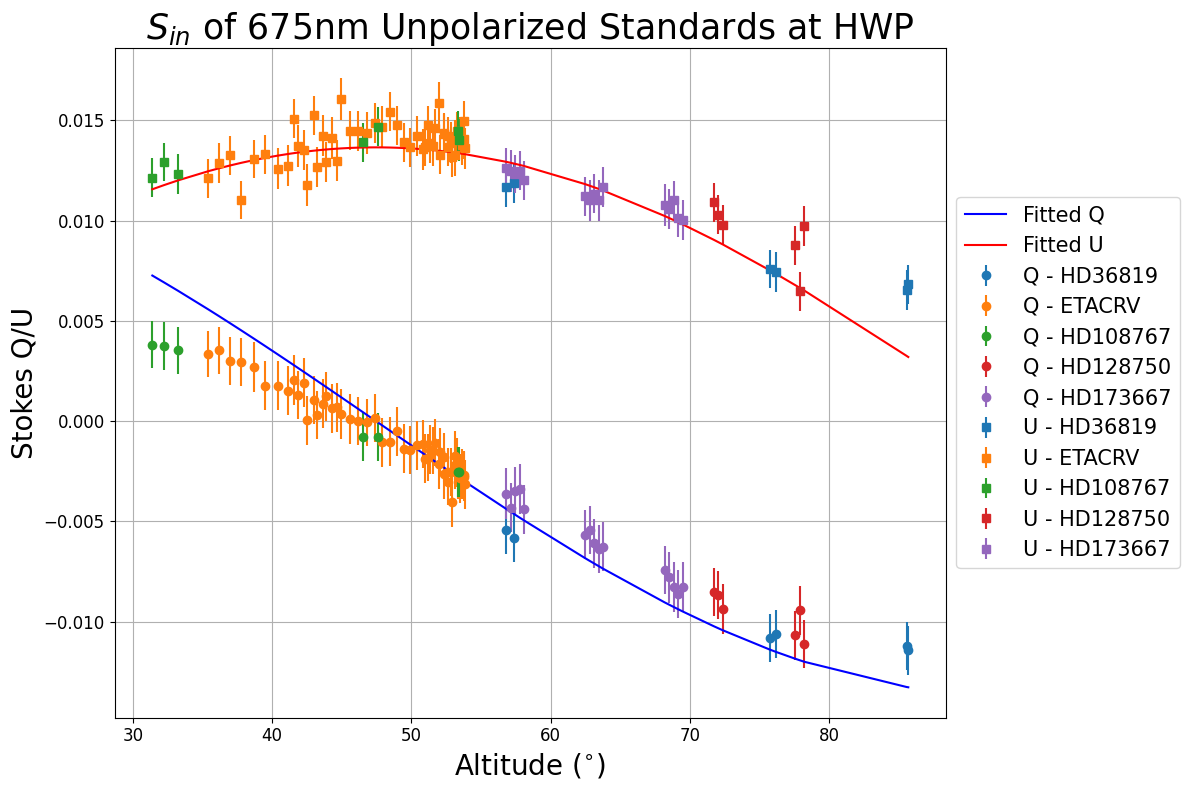

In [18]:
# Extract altitudes, Q_data, and U_data from the previous block of code
altitudes = [item[0] for item in Q_list]  # Extracting altitudes from Q_list (they are the same for U_list)
Q_data = np.array([item[1] for item in Q_list]).flatten()
U_data = np.array([item[1] for item in U_list]).flatten()

# Print the number of points for each target
unique_targets = set(item[3] for item in Q_list)
for target in unique_targets:
    count = sum(1 for item in Q_list if item[3] == target)
    print(f"Number of points for {target}: {count}")

# Initial guesses for delta_m3, epsilon_m3, and offset
initial_guesses = [0, 0.01, 1]
bounds = [(0, 1), (-0.5, 0.5), (-10, 10)]

# Perform the minimization using Nelder-Mead with bounds
result = minimize(m3.residuals, initial_guesses, args=(altitudes, Q_data, U_data), method='Nelder-Mead', bounds=bounds)

# Extract the best-fit parameters
delta_m3_best, epsilon_m3_best, offset_best = result.x

print("Best Fit M3 Diattenuation: " + str(epsilon_m3_best))
print("Best Fit Offset: " + str(offset_best))

# Calculate the fitted Q and U values
Q_fitted, U_fitted = m3.propagate_unpol_source(delta_m3_best, epsilon_m3_best, offset_best, altitudes)
#Q_fitted, U_fitted = m3.propagate_unpol_source(0, 0.0176, -2.5, altitudes)

# Sort the fitted values by altitude
sorted_indices = np.argsort(altitudes)
altitudes_sorted = np.array(altitudes)[sorted_indices]
Q_fitted_sorted = Q_fitted[sorted_indices]
U_fitted_sorted = U_fitted[sorted_indices]

# Plotting the data and the fitted line
plt.figure(figsize=(12, 8))
plotted_labels = set()
for (altitude, Q, color, obj), Q_err in zip(Q_list, Q_err_bootstrap):
    label = f'Q - {obj}' if f'Q - {obj}' not in plotted_labels else None
    plt.errorbar(altitude, Q, yerr=Q_err, label=label, linestyle='None', marker='o', color=color, markerfacecolor=color)
    plotted_labels.add(f'Q - {obj}')

for (altitude, U, color, obj), U_err in zip(U_list, U_err_bootstrap):
    label = f'U - {obj}' if f'U - {obj}' not in plotted_labels else None
    plt.errorbar(altitude, U, yerr=U_err, label=label, linestyle='None', marker='s', color=color, markerfacecolor=color, markeredgecolor=color)
    plotted_labels.add(f'U - {obj}')

# Plot the fitted line with different colors for Q and U
plt.plot(altitudes_sorted, Q_fitted_sorted, label='Fitted Q', linestyle='-', color='blue')
plt.plot(altitudes_sorted, U_fitted_sorted, label='Fitted U', linestyle='-', color='red')

# Manipulating font sizes

BIGGER_SIZE = 25
MEDIUM_SIZE = 20
FONT_SIZE = 15
TICK_SIZE = 12

plt.rc('figure', titlesize=BIGGER_SIZE)
plt.rc('axes', labelsize=MEDIUM_SIZE)
plt.rc('xtick', labelsize=TICK_SIZE)
plt.rc('ytick', labelsize=TICK_SIZE)

plt.title("$S_{in}$ of " + str(wavelength) + "nm Unpolarized Standards at HWP", fontsize=BIGGER_SIZE)
plt.xlabel("Altitude ($^{\circ}$)", fontsize=MEDIUM_SIZE)
plt.ylabel("Stokes Q/U", fontsize=MEDIUM_SIZE)
plt.legend(loc='center left', bbox_to_anchor=(1, 0.5), fontsize=FONT_SIZE)
plt.grid(True)
plt.tight_layout()
plt.show()


# Printing out number of points for each target

Best Fit M3 Diattenuation: 0.013654782151469173
Best Fit Offset: -2.459569446489333


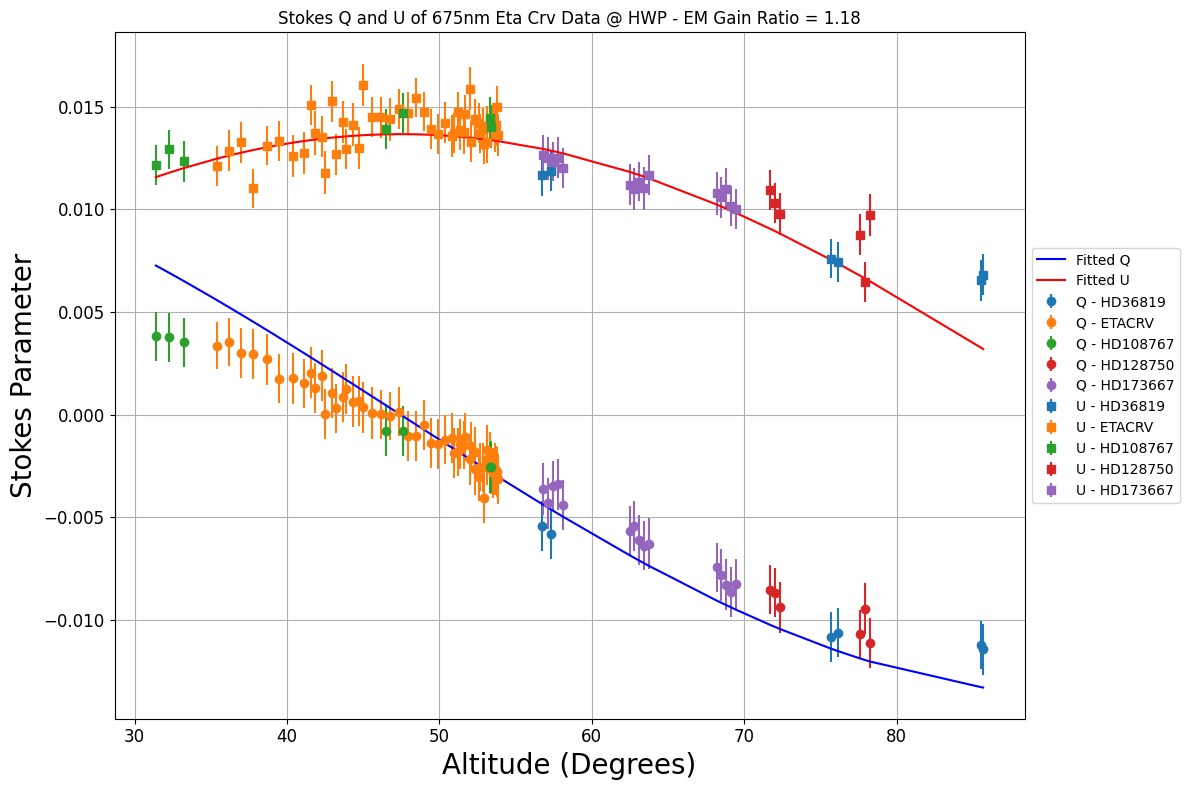

Number of points for HD36819: 12
Number of points for ETACRV: 104
Number of points for HD108767: 14
Number of points for HD128750: 12
Number of points for HD173667: 30


In [19]:
# Extract altitudes, Q_data, and U_data from the previous block of code
altitudes = [item[0] for item in Q_list]  # Extracting altitudes from Q_list (they are the same for U_list)
Q_data = np.array([item[1] for item in Q_list]).flatten()
U_data = np.array([item[1] for item in U_list]).flatten()

# Initial guesses for delta_m3, epsilon_m3, and offset
initial_guesses = [0, 0.01, 1]
bounds = [(0, 1), (-0.5, 0.5), (-10, 10)]

# Perform the minimization using Nelder-Mead with bounds
result = minimize(m3.residuals, initial_guesses, args=(altitudes, Q_data, U_data), method='Nelder-Mead', bounds=bounds)

# Extract the best-fit parameters
delta_m3_best, epsilon_m3_best, offset_best = result.x

print("Best Fit M3 Diattenuation: " + str(epsilon_m3_best))
print("Best Fit Offset: " + str(offset_best))

# Calculate the fitted Q and U values
Q_fitted, U_fitted = m3.propagate_unpol_source(delta_m3_best, epsilon_m3_best, offset_best, altitudes)

# Sort the fitted values by altitude
sorted_indices = np.argsort(altitudes)
altitudes_sorted = np.array(altitudes)[sorted_indices]
Q_fitted_sorted = Q_fitted[sorted_indices]
U_fitted_sorted = U_fitted[sorted_indices]

# Plotting the data and the fitted line
plt.figure(figsize=(12, 8))
plotted_labels = set()
points_count = {}

for (altitude, Q, color, obj), Q_err in zip(Q_list, Q_err_bootstrap):
    label = f'Q - {obj}' if f'Q - {obj}' not in plotted_labels else None
    plt.errorbar(altitude, Q, yerr=Q_err, label=label, linestyle='None', marker='o', color=color, markerfacecolor=color)
    plotted_labels.add(f'Q - {obj}')
    if obj not in points_count:
        points_count[obj] = 0
    points_count[obj] += 1

for (altitude, U, color, obj), U_err in zip(U_list, U_err_bootstrap):
    label = f'U - {obj}' if f'U - {obj}' not in plotted_labels else None
    plt.errorbar(altitude, U, yerr=U_err, label=label, linestyle='None', marker='s', color=color, markerfacecolor=color, markeredgecolor=color)
    plotted_labels.add(f'U - {obj}')
    if obj not in points_count:
        points_count[obj] = 0
    points_count[obj] += 1

# Plot the fitted line with different colors for Q and U
plt.plot(altitudes_sorted, Q_fitted_sorted, label='Fitted Q', linestyle='-', color='blue')
plt.plot(altitudes_sorted, U_fitted_sorted, label='Fitted U', linestyle='-', color='red')

plt.title(f"Stokes Q and U of {wavelength}nm Eta Crv Data @ HWP - EM Gain Ratio = " + str(em_gain))
plt.xlabel("Altitude (Degrees)")
plt.ylabel("Stokes Parameter")
plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))
plt.grid(True)
plt.tight_layout()
plt.show()

# Print the number of points for each target
for obj, count in points_count.items():
    print(f"Number of points for {obj}: {count}")


Best Fit M3 Diattenuation: 0.013654782151469173
Best Fit Offset: -2.459569446489333


/tmp/ipykernel_1565828/2582695950.py:51: RuntimeWarning: invalid value encountered in sqrt
  param_errors = np.sqrt(np.diag(cov_matrix))


Best Fit M3 Diattenuation Error: nan
Best Fit Offset Error: nan


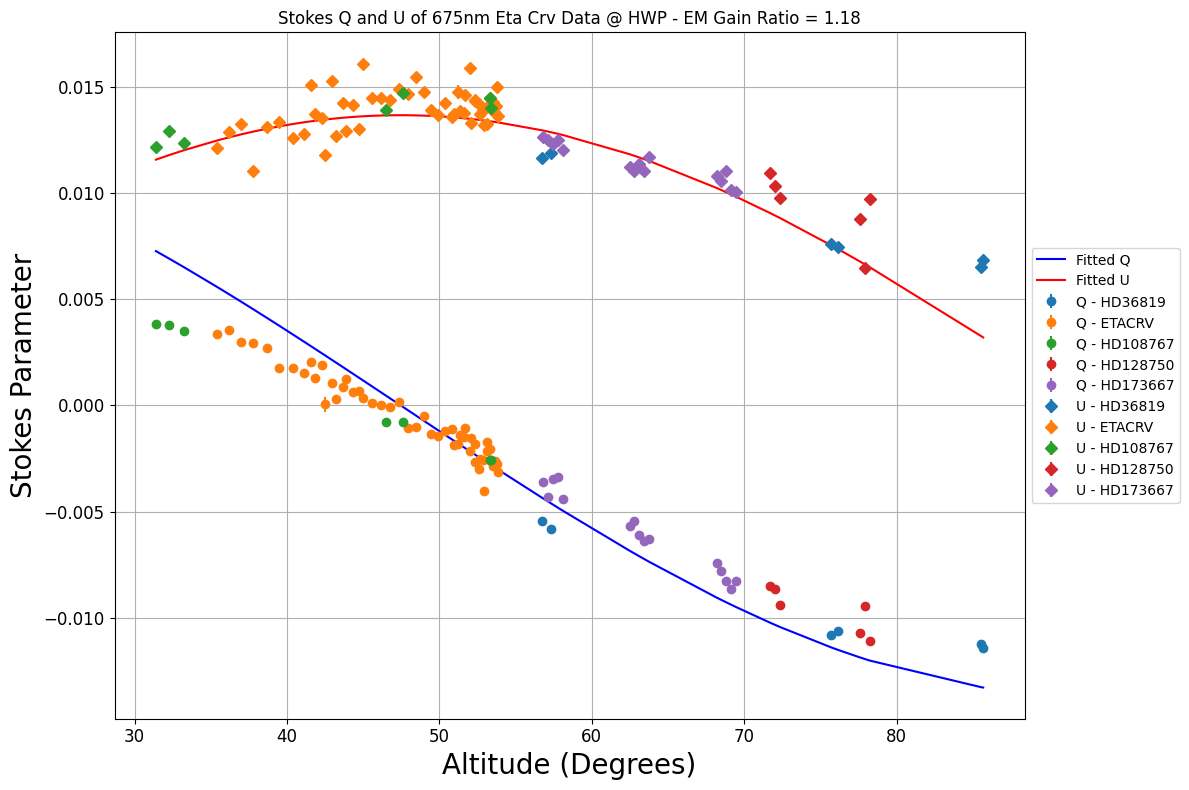

In [20]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize
from scipy.optimize import approx_fprime
from scipy.linalg import inv
import itertools

# Assuming m3.residuals and m3.propagate_unpol_source are already defined in your m3 module

# Extract altitudes, Q_data, and U_data from the previous block of code
altitudes = [item[0] for item in Q_list]  # Extracting altitudes from Q_list (they are the same for U_list)
Q_data = np.array([item[1] for item in Q_list]).flatten()
U_data = np.array([item[1] for item in U_list]).flatten()

# Initial guesses for delta_m3, epsilon_m3, and offset
initial_guesses = [0, 0.01, 1]
bounds = [(0, 1), (-0.5, 0.5), (-10, 10)]

# Perform the minimization using Nelder-Mead with bounds
result = minimize(m3.residuals, initial_guesses, args=(altitudes, Q_data, U_data), method='Nelder-Mead', bounds=bounds)

# Extract the best-fit parameters
delta_m3_best, epsilon_m3_best, offset_best = result.x

print("Best Fit M3 Diattenuation: " + str(epsilon_m3_best))
print("Best Fit Offset: " + str(offset_best))

# Calculate the fitted Q and U values
Q_fitted, U_fitted = m3.propagate_unpol_source(delta_m3_best, epsilon_m3_best, offset_best, altitudes)

# Sort the fitted values by altitude
sorted_indices = np.argsort(altitudes)
altitudes_sorted = np.array(altitudes)[sorted_indices]
Q_fitted_sorted = Q_fitted[sorted_indices]
U_fitted_sorted = U_fitted[sorted_indices]

# Calculate the covariance matrix using the Hessian
def fun(params):
    return np.sum(m3.residuals(params, altitudes, Q_data, U_data)**2)

# Approximate the Hessian using the Jacobian
eps = np.sqrt(np.finfo(float).eps)
jac = approx_fprime(result.x, fun, eps)
hess_inv = np.zeros((len(initial_guesses), len(initial_guesses)))

for i in range(len(initial_guesses)):
    for j in range(len(initial_guesses)):
        hess_inv[i, j] = (fun(result.x + eps * (i == j)) - fun(result.x)) / eps**2

cov_matrix = inv(hess_inv)
param_errors = np.sqrt(np.diag(cov_matrix))

delta_m3_err = param_errors[0]
epsilon_m3_err = param_errors[1]
offset_err = param_errors[2]

print("Best Fit M3 Diattenuation Error: " + str(epsilon_m3_err))
print("Best Fit Offset Error: " + str(offset_err))

# Plotting the data and the fitted line
plt.figure(figsize=(12, 8))
plotted_labels = set()
for (altitude, Q, color, obj), Q_err in zip(Q_list, Q_err_list):
    label = f'Q - {obj}' if f'Q - {obj}' not in plotted_labels else None
    plt.errorbar(altitude, Q, yerr=Q_err, label=label, linestyle='None', marker='o', color=color, markerfacecolor=color)
    plotted_labels.add(f'Q - {obj}')

for (altitude, U, color, obj), U_err in zip(U_list, U_err_list):
    label = f'U - {obj}' if f'U - {obj}' not in plotted_labels else None
    plt.errorbar(altitude, U, yerr=U_err, label=label, linestyle='None', marker='D', color=color, markerfacecolor=color, markeredgecolor=color)
    plotted_labels.add(f'U - {obj}')

# Plot the fitted line with different colors for Q and U
plt.plot(altitudes_sorted, Q_fitted_sorted, label='Fitted Q', linestyle='-', color='blue')
plt.plot(altitudes_sorted, U_fitted_sorted, label='Fitted U', linestyle='-', color='red')

plt.title(f"Stokes Q and U of {wavelength}nm Eta Crv Data @ HWP - EM Gain Ratio = " + str(em_gain))
plt.xlabel("Altitude (Degrees)")
plt.ylabel("Stokes Parameter")
plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))
plt.grid(True)
plt.tight_layout()
plt.show()


# Getting Errors on M3 Parameters

Best Fit M3 Diattenuation: 0.013654782151469173
Best Fit Offset: -2.459569446489333


/tmp/ipykernel_1565828/2582695950.py:51: RuntimeWarning: invalid value encountered in sqrt
  param_errors = np.sqrt(np.diag(cov_matrix))


Best Fit M3 Diattenuation Error: nan
Best Fit Offset Error: nan


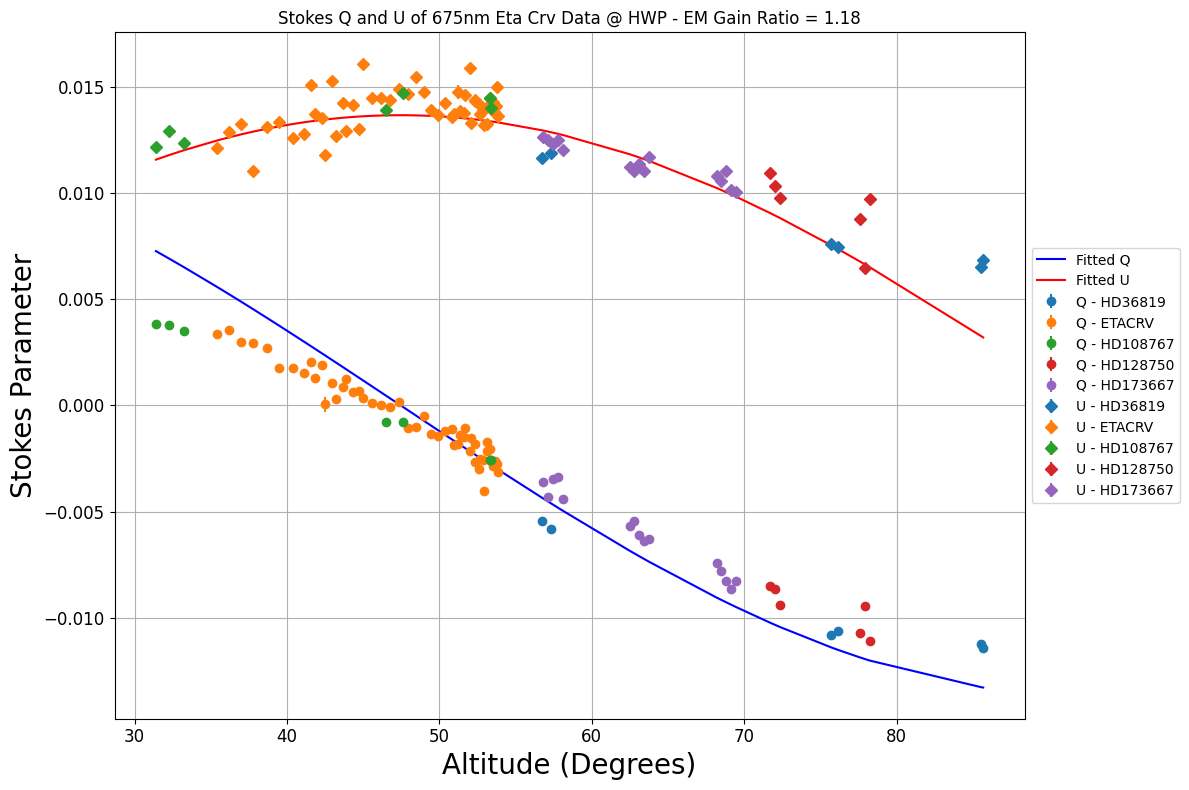

In [21]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize
from scipy.optimize import approx_fprime
from scipy.linalg import inv
import itertools

# Assuming m3.residuals and m3.propagate_unpol_source are already defined in your m3 module

# Extract altitudes, Q_data, and U_data from the previous block of code
altitudes = [item[0] for item in Q_list]  # Extracting altitudes from Q_list (they are the same for U_list)
Q_data = np.array([item[1] for item in Q_list]).flatten()
U_data = np.array([item[1] for item in U_list]).flatten()

# Initial guesses for delta_m3, epsilon_m3, and offset
initial_guesses = [0, 0.01, 1]
bounds = [(0, 1), (-0.5, 0.5), (-10, 10)]

# Perform the minimization using Nelder-Mead with bounds
result = minimize(m3.residuals, initial_guesses, args=(altitudes, Q_data, U_data), method='Nelder-Mead', bounds=bounds)

# Extract the best-fit parameters
delta_m3_best, epsilon_m3_best, offset_best = result.x

print("Best Fit M3 Diattenuation: " + str(epsilon_m3_best))
print("Best Fit Offset: " + str(offset_best))

# Calculate the fitted Q and U values
Q_fitted, U_fitted = m3.propagate_unpol_source(delta_m3_best, epsilon_m3_best, offset_best, altitudes)

# Sort the fitted values by altitude
sorted_indices = np.argsort(altitudes)
altitudes_sorted = np.array(altitudes)[sorted_indices]
Q_fitted_sorted = Q_fitted[sorted_indices]
U_fitted_sorted = U_fitted[sorted_indices]

# Calculate the covariance matrix using the Hessian
def fun(params):
    return np.sum(m3.residuals(params, altitudes, Q_data, U_data)**2)

# Approximate the Hessian using the Jacobian
eps = np.sqrt(np.finfo(float).eps)
jac = approx_fprime(result.x, fun, eps)
hess_inv = np.zeros((len(initial_guesses), len(initial_guesses)))

for i in range(len(initial_guesses)):
    for j in range(len(initial_guesses)):
        hess_inv[i, j] = (fun(result.x + eps * (i == j)) - fun(result.x)) / eps**2

cov_matrix = inv(hess_inv)
param_errors = np.sqrt(np.diag(cov_matrix))

delta_m3_err = param_errors[0]
epsilon_m3_err = param_errors[1]
offset_err = param_errors[2]

print("Best Fit M3 Diattenuation Error: " + str(epsilon_m3_err))
print("Best Fit Offset Error: " + str(offset_err))

# Plotting the data and the fitted line
plt.figure(figsize=(12, 8))
plotted_labels = set()
for (altitude, Q, color, obj), Q_err in zip(Q_list, Q_err_list):
    label = f'Q - {obj}' if f'Q - {obj}' not in plotted_labels else None
    plt.errorbar(altitude, Q, yerr=Q_err, label=label, linestyle='None', marker='o', color=color, markerfacecolor=color)
    plotted_labels.add(f'Q - {obj}')

for (altitude, U, color, obj), U_err in zip(U_list, U_err_list):
    label = f'U - {obj}' if f'U - {obj}' not in plotted_labels else None
    plt.errorbar(altitude, U, yerr=U_err, label=label, linestyle='None', marker='D', color=color, markerfacecolor=color, markeredgecolor=color)
    plotted_labels.add(f'U - {obj}')

# Plot the fitted line with different colors for Q and U
plt.plot(altitudes_sorted, Q_fitted_sorted, label='Fitted Q', linestyle='-', color='blue')
plt.plot(altitudes_sorted, U_fitted_sorted, label='Fitted U', linestyle='-', color='red')

plt.title(f"Stokes Q and U of {wavelength}nm Eta Crv Data @ HWP - EM Gain Ratio = " + str(em_gain))
plt.xlabel("Altitude (Degrees)")
plt.ylabel("Stokes Parameter")
plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))
plt.grid(True)
plt.tight_layout()
plt.show()


# Trying again

Best Fit M3 Diattenuation: 0.013654815461338812
Best Fit Offset: -2.4594180154633745
Best Fit M3 Diattenuation Error: 9984.247125252763
Best Fit Offset Error: 9984.247125252763


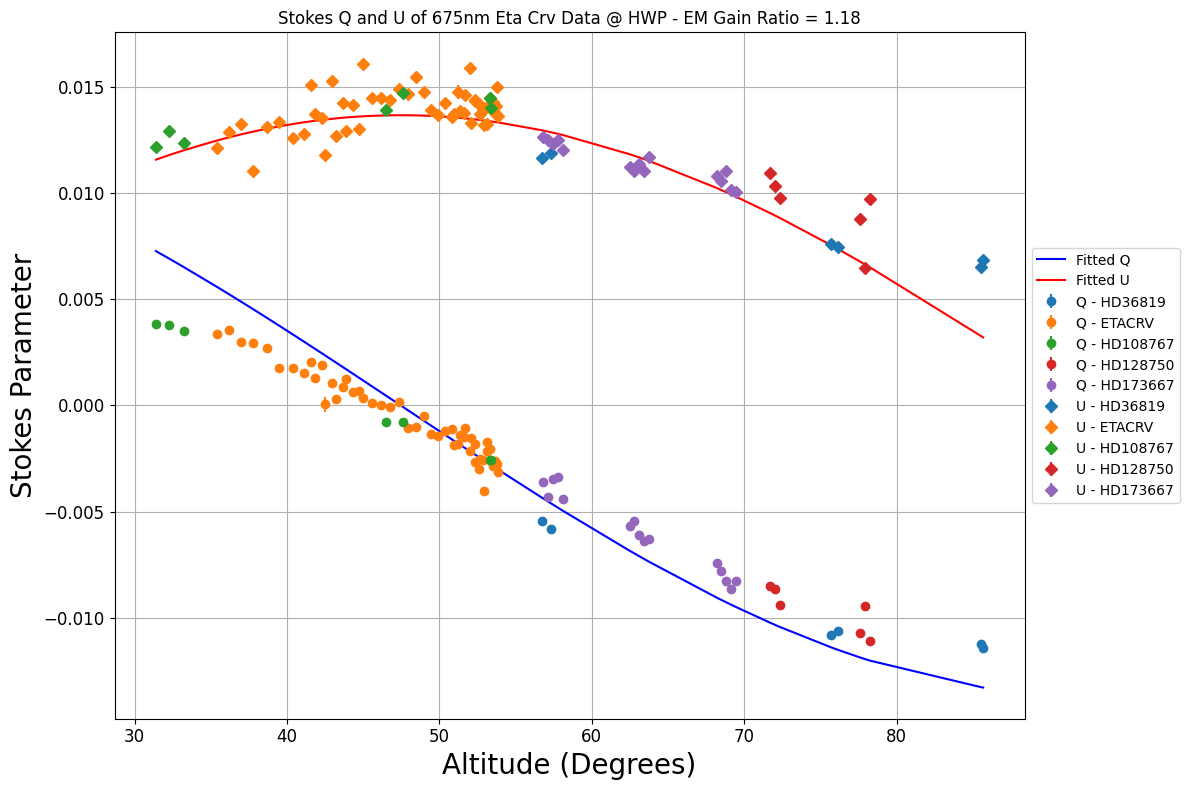

In [22]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize
from scipy.optimize import approx_fprime
from scipy.linalg import inv
import itertools

# Assuming m3.residuals and m3.propagate_unpol_source are already defined in your m3 module

# Extract altitudes, Q_data, and U_data from the previous block of code
altitudes = [item[0] for item in Q_list]  # Extracting altitudes from Q_list (they are the same for U_list)
Q_data = np.array([item[1] for item in Q_list]).flatten()
U_data = np.array([item[1] for item in U_list]).flatten()

# Initial guesses for delta_m3, epsilon_m3, and offset
initial_guesses = [0, 0.01, 1]
bounds = [(0, 1), (-0.5, 0.5), (-10, 10)]

# Perform the minimization using BFGS with bounds
result = minimize(m3.residuals, initial_guesses, args=(altitudes, Q_data, U_data), method='L-BFGS-B', bounds=bounds)

# Extract the best-fit parameters
delta_m3_best, epsilon_m3_best, offset_best = result.x

print("Best Fit M3 Diattenuation: " + str(epsilon_m3_best))
print("Best Fit Offset: " + str(offset_best))

# Calculate the fitted Q and U values
Q_fitted, U_fitted = m3.propagate_unpol_source(delta_m3_best, epsilon_m3_best, offset_best, altitudes)

# Sort the fitted values by altitude
sorted_indices = np.argsort(altitudes)
altitudes_sorted = np.array(altitudes)[sorted_indices]
Q_fitted_sorted = Q_fitted[sorted_indices]
U_fitted_sorted = U_fitted[sorted_indices]

# Calculate the Jacobian at the best-fit parameters
def fun(params):
    return m3.residuals(params, altitudes, Q_data, U_data)

eps = np.sqrt(np.finfo(float).eps)
jacobian = approx_fprime(result.x, fun, eps)

# Calculate the Hessian matrix using the Jacobian
hessian = np.dot(jacobian.T, jacobian)

# Regularize the Hessian matrix by adding a small value to the diagonal
regularization = 1e-8
hessian += np.eye(len(initial_guesses)) * regularization

# Check if Hessian is invertible and calculate the covariance matrix
try:
    cov_matrix = inv(hessian)
    param_errors = np.sqrt(np.diag(cov_matrix))
except np.linalg.LinAlgError:
    param_errors = np.full(len(initial_guesses), np.nan)

delta_m3_err = param_errors[0]
epsilon_m3_err = param_errors[1]
offset_err = param_errors[2]

print("Best Fit M3 Diattenuation Error: " + str(epsilon_m3_err))
print("Best Fit Offset Error: " + str(offset_err))

# Plotting the data and the fitted line
plt.figure(figsize=(12, 8))
plotted_labels = set()
for (altitude, Q, color, obj), Q_err in zip(Q_list, Q_err_list):
    label = f'Q - {obj}' if f'Q - {obj}' not in plotted_labels else None
    plt.errorbar(altitude, Q, yerr=Q_err, label=label, linestyle='None', marker='o', color=color, markerfacecolor=color)
    plotted_labels.add(f'Q - {obj}')

for (altitude, U, color, obj), U_err in zip(U_list, U_err_list):
    label = f'U - {obj}' if f'U - {obj}' not in plotted_labels else None
    plt.errorbar(altitude, U, yerr=U_err, label=label, linestyle='None', marker='D', color=color, markerfacecolor=color, markeredgecolor=color)
    plotted_labels.add(f'U - {obj}')

# Plot the fitted line with different colors for Q and U
plt.plot(altitudes_sorted, Q_fitted_sorted, label='Fitted Q', linestyle='-', color='blue')
plt.plot(altitudes_sorted, U_fitted_sorted, label='Fitted U', linestyle='-', color='red')

plt.title(f"Stokes Q and U of {wavelength}nm Eta Crv Data @ HWP - EM Gain Ratio = " + str(em_gain))
plt.xlabel("Altitude (Degrees)")
plt.ylabel("Stokes Parameter")
plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))
plt.grid(True)
plt.tight_layout()
plt.show()
